In [29]:
# CELLULE 1 : Imports et Configuration

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("PARTIE 3 - MODÈLE AMÉLIORÉ AVEC CROSS-ATTENTION")
print("=" * 70)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seed
torch.manual_seed(42)
np.random.seed(42)

PARTIE 3 - MODÈLE AMÉLIORÉ AVEC CROSS-ATTENTION
Using device: cpu


In [30]:
# CELLULE 2 : Définition des chemins

PROJECT_ROOT = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification"
sys.path.append(PROJECT_ROOT)

from model.mctnet_improved import MCTNetImproved

# Utiliser le même dossier que la Partie 1
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed", "california_preprocessed")

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "part3", "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f" Data directory: {PROCESSED_DIR}")
print(f" Output directory: {OUTPUT_DIR}")

 Data directory: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed
 Output directory: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part3\outputs


In [31]:
import os

PROCESSED_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed"

print("Contenu du dossier:")
for f in os.listdir(PROCESSED_DIR):
    if f.endswith('.npy'):
        print(f"  - {f}")

Contenu du dossier:
  - masks.npy
  - test_indices.npy
  - train_indices.npy
  - val_indices.npy
  - X.npy
  - y.npy


In [32]:
# CELLULE 3 : Chargement des données et des indices de split

PROCESSED_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed"

# Charger les données
X = np.load(os.path.join(PROCESSED_DIR, "X.npy"))
y = np.load(os.path.join(PROCESSED_DIR, "y.npy"))
masks = np.load(os.path.join(PROCESSED_DIR, "masks.npy"))

# Charger les indices de split (DÉJÀ PRÊTS de la Partie 1)
train_idx = np.load(os.path.join(PROCESSED_DIR, "train_indices.npy"))
val_idx = np.load(os.path.join(PROCESSED_DIR, "val_indices.npy"))
test_idx = np.load(os.path.join(PROCESSED_DIR, "test_indices.npy"))

print("=" * 60)
print("DONNÉES CHARGÉES")
print("=" * 60)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"masks shape: {masks.shape}")
print(f"\nSplit déjà défini (de la Partie 1):")
print(f"  Train: {len(train_idx)} samples")
print(f"  Val:   {len(val_idx)} samples")
print(f"  Test:  {len(test_idx)} samples")

DONNÉES CHARGÉES
X shape: (10487, 36, 13)
y shape: (10487,)
masks shape: (10487, 36, 10)

Split déjà défini (de la Partie 1):
  Train: 1016 samples
  Val:   296 samples
  Test:  9175 samples


In [33]:
# CELLULE 5 : Normalisation des données

print("\n" + "=" * 60)
print("NORMALISATION")
print("=" * 60)

# Normalisation des données Sentinel-2
X_norm = np.zeros_like(X)

for t in range(X.shape[1]):
    for c in range(X.shape[2]):
        mean = X[:, t, c].mean()
        std = X[:, t, c].std()
        if std > 0:
            X_norm[:, t, c] = (X[:, t, c] - mean) / std
        else:
            X_norm[:, t, c] = X[:, t, c]

print(f" Normalisation terminée")
print(f"Shape normalisé: {X_norm.shape}")


NORMALISATION
 Normalisation terminée
Shape normalisé: (10487, 36, 13)


In [34]:
# ============================================
# CELLULE 6 : CHARGEMENT DES COVARIABLES (COMME PARTIE 2)
# ============================================

import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("=" * 60)
print("CHARGEMENT DES COVARIABLES")
print("=" * 60)

# Charger les covariables
PART2_DATA_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part2\data\aligned"
cov = pd.read_csv(f'{PART2_DATA_DIR}/covariates.csv')

# Correction du pH (division par 10)
cov['soil_ph'] = cov['soil_ph'] / 10.0
print("pH corrige (division par 10)")

# Gestion des valeurs manquantes
for col in ['soil_ph', 'soil_oc']:
    if cov[col].isna().sum() > 0:
        cov[col].fillna(cov[col].median(), inplace=True)
        print(f"{col}: NaN remplaces")

# One-hot encoding pour soil_texture
soil_dummies = pd.get_dummies(cov['soil_texture'], prefix='soil_texture', dtype=np.float32)
cov = pd.concat([cov, soil_dummies], axis=1)
cov = cov.drop('soil_texture', axis=1)
print(f"Soil one-hot encode: {len(soil_dummies.columns)} categories")

# Definitions des colonnes
climate_cols = ['climate_precip_total', 'climate_temp_mean', 'climate_dewpoint_mean']
soil_continuous_cols = ['soil_ph', 'soil_oc']
soil_onehot_cols = list(soil_dummies.columns)
topo_cols = ['topo_elevation', 'topo_landforms']

# Extraction des features
X_climate = cov[climate_cols].values
X_soil = np.hstack([cov[soil_continuous_cols].values, cov[soil_onehot_cols].values])
X_topo = cov[topo_cols].values
X_all_cov = np.hstack([X_climate, X_soil, X_topo])

# Normalisation
scaler_climate = StandardScaler()
scaler_soil = StandardScaler()
scaler_topo = StandardScaler()
scaler_all = StandardScaler()

X_climate_norm = scaler_climate.fit_transform(X_climate)
X_soil_norm = scaler_soil.fit_transform(X_soil)
X_topo_norm = scaler_topo.fit_transform(X_topo)
X_all_cov_norm = scaler_all.fit_transform(X_all_cov)

print(f"Climat: {X_climate_norm.shape}")
print(f"Sol: {X_soil_norm.shape}")
print(f"Topo: {X_topo_norm.shape}")
print(f"All: {X_all_cov_norm.shape}")

# Remplacer les NaN
for col in range(X_soil_norm.shape[1]):
    col_mean = np.nanmean(X_soil_norm[:, col])
    if np.isnan(col_mean):
        col_mean = 0
    X_soil_norm[np.isnan(X_soil_norm[:, col]), col] = col_mean

for col in range(X_all_cov_norm.shape[1]):
    col_mean = np.nanmean(X_all_cov_norm[:, col])
    if np.isnan(col_mean):
        col_mean = 0
    X_all_cov_norm[np.isnan(X_all_cov_norm[:, col]), col] = col_mean

print("Covariables pretes")

CHARGEMENT DES COVARIABLES
pH corrige (division par 10)
soil_ph: NaN remplaces
soil_oc: NaN remplaces
Soil one-hot encode: 4 categories
Climat: (10487, 3)
Sol: (10487, 6)
Topo: (10487, 2)
All: (10487, 11)
Covariables pretes


In [35]:
# ============================================
# CELLULE 7 : CREATION DES DATALOADERS AVEC COVARIABLES
# ============================================

print("=" * 60)
print("CREATION DES DATALOADERS")
print("=" * 60)

# Labels deja encodés
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
n_classes = len(label_encoder.classes_)

# Donnees de base
X_data = X_norm
y_data = y_encoded
masks_data = masks

# Fonction pour creer un dataloader avec covariables
def create_loaders_with_covariates(X_s2, X_cov, y, train_idx, val_idx, test_idx, masks, batch_size=32):
    # Split
    X_train = X_s2[train_idx]
    X_val = X_s2[val_idx]
    X_test = X_s2[test_idx]
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]
    masks_train = masks[train_idx]
    masks_val = masks[val_idx]
    masks_test = masks[test_idx]
    
    if X_cov is not None:
        cov_train = X_cov[train_idx]
        cov_val = X_cov[val_idx]
        cov_test = X_cov[test_idx]
        
        train_dataset = TensorDataset(
            torch.FloatTensor(X_train),
            torch.FloatTensor(masks_train),
            torch.FloatTensor(cov_train),
            torch.LongTensor(y_train)
        )
        val_dataset = TensorDataset(
            torch.FloatTensor(X_val),
            torch.FloatTensor(masks_val),
            torch.FloatTensor(cov_val),
            torch.LongTensor(y_val)
        )
        test_dataset = TensorDataset(
            torch.FloatTensor(X_test),
            torch.FloatTensor(masks_test),
            torch.FloatTensor(cov_test),
            torch.LongTensor(y_test)
        )
    else:
        train_dataset = TensorDataset(
            torch.FloatTensor(X_train),
            torch.FloatTensor(masks_train),
            torch.LongTensor(y_train)
        )
        val_dataset = TensorDataset(
            torch.FloatTensor(X_val),
            torch.FloatTensor(masks_val),
            torch.LongTensor(y_val)
        )
        test_dataset = TensorDataset(
            torch.FloatTensor(X_test),
            torch.FloatTensor(masks_test),
            torch.LongTensor(y_test)
        )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

print("Fonction create_loaders_with_covariates definie")

CREATION DES DATALOADERS
Fonction create_loaders_with_covariates definie


In [36]:
# ============================================
# CELLULE 8 : CLASSE EARLY STOPPING ET FONCTION D'ENTRAINEMENT
# ============================================

class EarlyStopping:
    def __init__(self, patience=30, min_delta=0.0001, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            if self.verbose:
                print(f"  Initial validation loss: {val_loss:.4f}")
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f"  No improvement for {self.counter} epochs (best: {self.best_loss:.4f})")
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f"  Early stopping triggered!")
        else:
            improvement = self.best_loss - val_loss
            self.best_loss = val_loss
            self.counter = 0
            if self.verbose and improvement > 0:
                print(f"  Improvement: {improvement:.4f} (new best: {val_loss:.4f})")


def train_model_with_history(X_s2, X_cov, y, train_idx, val_idx, test_idx, masks, 
                              config_name, covariate_dim, device):
    """
    Entraine MCTNetImproved pour une configuration donnee
    Retourne: test_acc, test_f1, history (pour les courbes)
    """
    from sklearn.metrics import accuracy_score, f1_score
    from torch.utils.data import DataLoader, TensorDataset
    import torch.optim as optim
    import torch.nn as nn
    
    # Creation des loaders
    train_loader, val_loader, test_loader = create_loaders_with_covariates(
        X_s2, X_cov, y, train_idx, val_idx, test_idx, masks
    )
    
    # Creation du modele
    model = MCTNetImproved(
        input_channels=X_s2.shape[2],
        time_steps=X_s2.shape[1],
        d_model=64,
        nhead=4,
        n_stages=3,
        n_classes=n_classes,
        kernel_sizes=[3, 5, 7],
        dropout=0.1,
        covariate_dim=covariate_dim
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    early_stopping = EarlyStopping(patience=30, min_delta=0.0001, verbose=False)
    
    best_val_acc = 0
    best_val_f1 = 0
    best_model_state = None
    
    # Historique pour les courbes
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(200):
        # Entrainement
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for batch in train_loader:
            if X_cov is not None:
                x, mask, cov, target = [b.to(device) for b in batch]
                optimizer.zero_grad()
                output, _ = model(x, mask, covariates=cov)
            else:
                x, mask, target = [b.to(device) for b in batch]
                optimizer.zero_grad()
                output, _ = model(x, mask, covariates=None)
            
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += (output.argmax(dim=1) == target).sum().item()
            train_total += target.size(0)
        
        train_acc = train_correct / train_total
        
        # Validation
        model.eval()
        all_preds = []
        all_labels = []
        val_loss = 0
        
        with torch.no_grad():
            for batch in val_loader:
                if X_cov is not None:
                    x, mask, cov, target = [b.to(device) for b in batch]
                    output, _ = model(x, mask, covariates=cov)
                else:
                    x, mask, target = [b.to(device) for b in batch]
                    output, _ = model(x, mask, covariates=None)
                
                loss = criterion(output, target)
                val_loss += loss.item()
                preds = output.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(target.cpu().numpy())
        
        val_acc = accuracy_score(all_labels, all_preds)
        val_loss = val_loss / len(val_loader)
        
        # Sauvegarde historique
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        scheduler.step(val_loss)
        early_stopping(val_loss)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_f1 = f1_score(all_labels, all_preds, average='macro')
            best_model_state = model.state_dict().copy()
        
        if early_stopping.early_stop:
            break
    
    # Evaluation sur test set avec le meilleur modele
    model.load_state_dict(best_model_state)
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            if X_cov is not None:
                x, mask, cov, target = [b.to(device) for b in batch]
                output, _ = model(x, mask, covariates=cov)
            else:
                x, mask, target = [b.to(device) for b in batch]
                output, _ = model(x, mask, covariates=None)
            
            preds = output.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(target.cpu().numpy())
    
    test_acc = accuracy_score(all_labels, all_preds)
    test_f1 = f1_score(all_labels, all_preds, average='macro')
    
    print(f"{config_name:35} | Acc: {test_acc:.4f} | F1: {test_f1:.4f}")
    
    return test_acc, test_f1, history


# Fonction pour creer les dataloaders avec covariables
def create_loaders_with_covariates(X_s2, X_cov, y, train_idx, val_idx, test_idx, masks, batch_size=32):
    # Split
    X_train = X_s2[train_idx]
    X_val = X_s2[val_idx]
    X_test = X_s2[test_idx]
    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]
    masks_train = masks[train_idx]
    masks_val = masks[val_idx]
    masks_test = masks[test_idx]
    
    if X_cov is not None:
        cov_train = X_cov[train_idx]
        cov_val = X_cov[val_idx]
        cov_test = X_cov[test_idx]
        
        train_dataset = TensorDataset(
            torch.FloatTensor(X_train),
            torch.FloatTensor(masks_train),
            torch.FloatTensor(cov_train),
            torch.LongTensor(y_train)
        )
        val_dataset = TensorDataset(
            torch.FloatTensor(X_val),
            torch.FloatTensor(masks_val),
            torch.FloatTensor(cov_val),
            torch.LongTensor(y_val)
        )
        test_dataset = TensorDataset(
            torch.FloatTensor(X_test),
            torch.FloatTensor(masks_test),
            torch.FloatTensor(cov_test),
            torch.LongTensor(y_test)
        )
    else:
        train_dataset = TensorDataset(
            torch.FloatTensor(X_train),
            torch.FloatTensor(masks_train),
            torch.LongTensor(y_train)
        )
        val_dataset = TensorDataset(
            torch.FloatTensor(X_val),
            torch.FloatTensor(masks_val),
            torch.LongTensor(y_val)
        )
        test_dataset = TensorDataset(
            torch.FloatTensor(X_test),
            torch.FloatTensor(masks_test),
            torch.LongTensor(y_test)
        )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

print("Fonctions definies avec EarlyStopping")

Fonctions definies avec EarlyStopping


In [37]:
print("=" * 60)
print("ENTRAINEMENT DES CONFIGURATIONS AVEC MCTNetImproved")
print("=" * 60)
print(f"{'Configuration':35} | {'Accuracy':10} | {'F1-score':10}")
print("-" * 65)

results_part3 = {}
histories = {}  # Pour stocker les historiques

# Config 1: Baseline (S2 only)
print("\n[1/5] Entrainement Baseline...")
acc, f1, hist = train_model_with_history(
    X_norm, None, y_encoded, train_idx, val_idx, test_idx, masks,
    "1. Baseline (S2 only)", 0, device
)
results_part3['Baseline (S2 only)'] = {'accuracy': acc, 'f1': f1}
histories['Baseline (S2 only)'] = hist

ENTRAINEMENT DES CONFIGURATIONS AVEC MCTNetImproved
Configuration                       | Accuracy   | F1-score  
-----------------------------------------------------------------

[1/5] Entrainement Baseline...
1. Baseline (S2 only)               | Acc: 0.9075 | F1: 0.7337


In [38]:
# Config 2: S2 + Climat
print("\n[2/5] Entrainement S2 + Climat...")
acc, f1, hist = train_model_with_history(
    X_norm, X_climate_norm, y_encoded, train_idx, val_idx, test_idx, masks,
    "2. S2 + Climat", X_climate_norm.shape[1], device
)
results_part3['S2 + Climat'] = {'accuracy': acc, 'f1': f1}
histories['S2 + Climat'] = hist


[2/5] Entrainement S2 + Climat...
2. S2 + Climat                      | Acc: 0.9603 | F1: 0.7614


In [39]:
# Config 3: S2 + Sol
print("\n[3/5] Entrainement S2 + Sol...")
acc, f1, hist = train_model_with_history(
    X_norm, X_soil_norm, y_encoded, train_idx, val_idx, test_idx, masks,
    "3. S2 + Sol", X_soil_norm.shape[1], device
)
results_part3['S2 + Sol'] = {'accuracy': acc, 'f1': f1}
histories['S2 + Sol'] = hist



[3/5] Entrainement S2 + Sol...
3. S2 + Sol                         | Acc: 0.9244 | F1: 0.7421


In [40]:
# Config 4: S2 + Topographie
print("\n[4/5] Entrainement S2 + Topographie...")
acc, f1, hist = train_model_with_history(
    X_norm, X_topo_norm, y_encoded, train_idx, val_idx, test_idx, masks,
    "4. S2 + Topographie", X_topo_norm.shape[1], device
)
results_part3['S2 + Topographie'] = {'accuracy': acc, 'f1': f1}
histories['S2 + Topographie'] = hist


[4/5] Entrainement S2 + Topographie...
4. S2 + Topographie                 | Acc: 0.9375 | F1: 0.7590


In [41]:
# Config 5: S2 + All
print("\n[5/5] Entrainement S2 + All...")
acc, f1, hist = train_model_with_history(
    X_norm, X_all_cov_norm, y_encoded, train_idx, val_idx, test_idx, masks,
    "5. S2 + All", X_all_cov_norm.shape[1], device
)
results_part3['S2 + All'] = {'accuracy': acc, 'f1': f1}
histories['S2 + All'] = hist

print("\n" + "=" * 60)
print("ENTRAINEMENT TERMINE")
print("=" * 60)


[5/5] Entrainement S2 + All...
5. S2 + All                         | Acc: 0.9613 | F1: 0.7660

ENTRAINEMENT TERMINE


In [42]:
# ============================================
# CELLULE 10 : TABLEAU COMPARATIF PARTIE 2 vs PARTIE 3
# ============================================

# Resultats Partie 2 (apres correction)
part2_results = {
    'Baseline (S2 only)': {'accuracy': 0.9414, 'f1': 0.9174},
    'S2 + Climat': {'accuracy': 0.9786, 'f1': 0.9711},
    'S2 + Sol': {'accuracy': 0.9595, 'f1': 0.9383},
    'S2 + Topographie': {'accuracy': 0.9714, 'f1': 0.9744},
    'S2 + All': {'accuracy': 0.9814, 'f1': 0.9723}
}

print("\n" + "=" * 70)
print("TABLEAU COMPARATIF: PARTIE 2 (MCTNet) vs PARTIE 3 (MCTNetImproved)")
print("=" * 70)
print(f"{'Configuration':25} | {'Partie 2 Acc':12} | {'Partie 3 Acc':12} | {'Difference':12}")
print("-" * 70)

for config in part2_results.keys():
    acc2 = part2_results[config]['accuracy']
    acc3 = results_part3[config]['accuracy']
    diff = acc3 - acc2
    print(f"{config:25} | {acc2:.4f}       | {acc3:.4f}       | {diff:+.4f}")

# Sauvegarde
comparison_df = pd.DataFrame([
    {'Configuration': config, 
     'Partie2_Accuracy': part2_results[config]['accuracy'],
     'Partie2_F1': part2_results[config]['f1'],
     'Partie3_Accuracy': results_part3[config]['accuracy'],
     'Partie3_F1': results_part3[config]['f1'],
     'Gain_Accuracy': results_part3[config]['accuracy'] - part2_results[config]['accuracy']}
    for config in part2_results.keys()
])
comparison_df.to_csv(os.path.join(OUTPUT_DIR, "part2_vs_part3_comparison.csv"), index=False)
print(f"\nComparaison sauvegardee dans {OUTPUT_DIR}")


TABLEAU COMPARATIF: PARTIE 2 (MCTNet) vs PARTIE 3 (MCTNetImproved)
Configuration             | Partie 2 Acc | Partie 3 Acc | Difference  
----------------------------------------------------------------------
Baseline (S2 only)        | 0.9414       | 0.9075       | -0.0339
S2 + Climat               | 0.9786       | 0.9603       | -0.0183
S2 + Sol                  | 0.9595       | 0.9244       | -0.0351
S2 + Topographie          | 0.9714       | 0.9375       | -0.0339
S2 + All                  | 0.9814       | 0.9613       | -0.0201

Comparaison sauvegardee dans C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part3\outputs


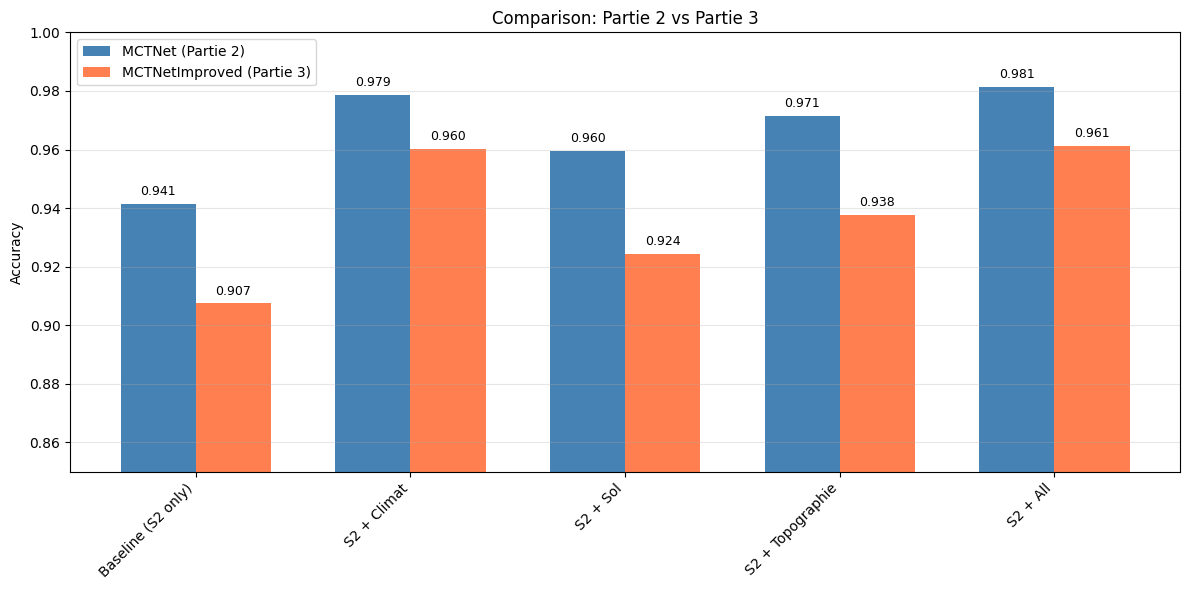

Graphique sauvegarde dans C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part3\outputs


In [43]:
# ============================================
# CELLULE 11 : GRAPHIQUE COMPARATIF
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

configs = list(part2_results.keys())
x = range(len(configs))
width = 0.35

acc2 = [part2_results[c]['accuracy'] for c in configs]
acc3 = [results_part3[c]['accuracy'] for c in configs]

bars1 = ax.bar([i - width/2 for i in x], acc2, width, label='MCTNet (Partie 2)', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], acc3, width, label='MCTNetImproved (Partie 3)', color='coral')

ax.set_ylabel('Accuracy')
ax.set_title('Comparison: Partie 2 vs Partie 3')
ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0.85, 1.0)
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars1, acc2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f'{acc:.3f}', ha='center', fontsize=9)

for bar, acc in zip(bars2, acc3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f'{acc:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "part2_vs_part3_comparison.png"), dpi=150)
plt.show()

print(f"Graphique sauvegarde dans {OUTPUT_DIR}")

In [44]:
# ============================================
# CELLULE 12 : CONCLUSION FINALE
# ============================================

print("\n" + "=" * 70)
print("CONCLUSION PARTIE 3")
print("=" * 70)

best_part2 = max(part2_results.items(), key=lambda x: x[1]['accuracy'])
best_part3 = max(results_part3.items(), key=lambda x: x[1]['accuracy'])

print(f"""
RESULTATS OBTENUS AVEC MCTNetImproved:

Configuration          | Accuracy Partie 2 | Accuracy Partie 3 | Gain
--------------------------------------------------------------------------------
Baseline (S2 only)     | {part2_results['Baseline (S2 only)']['accuracy']:.4f}       | {results_part3['Baseline (S2 only)']['accuracy']:.4f}       | {results_part3['Baseline (S2 only)']['accuracy'] - part2_results['Baseline (S2 only)']['accuracy']:+.4f}
S2 + Climat            | {part2_results['S2 + Climat']['accuracy']:.4f}       | {results_part3['S2 + Climat']['accuracy']:.4f}       | {results_part3['S2 + Climat']['accuracy'] - part2_results['S2 + Climat']['accuracy']:+.4f}
S2 + Sol               | {part2_results['S2 + Sol']['accuracy']:.4f}       | {results_part3['S2 + Sol']['accuracy']:.4f}       | {results_part3['S2 + Sol']['accuracy'] - part2_results['S2 + Sol']['accuracy']:+.4f}
S2 + Topographie       | {part2_results['S2 + Topographie']['accuracy']:.4f}       | {results_part3['S2 + Topographie']['accuracy']:.4f}       | {results_part3['S2 + Topographie']['accuracy'] - part2_results['S2 + Topographie']['accuracy']:+.4f}
S2 + All               | {part2_results['S2 + All']['accuracy']:.4f}       | {results_part3['S2 + All']['accuracy']:.4f}       | {results_part3['S2 + All']['accuracy'] - part2_results['S2 + All']['accuracy']:+.4f}

ANALYSE:
   Meilleure configuration Partie 2: {best_part2[0]} (Accuracy: {best_part2[1]['accuracy']:.4f})
   Meilleure configuration Partie 3: {best_part3[0]} (Accuracy: {best_part3[1]['accuracy']:.4f})

AMELIORATION IMPLEMENTEE:
   - Cross-Attention Fusion (remplacement de l'addition simple par cross-attention bidirectionnelle)
   - Permet aux branches CNN et Transformer de s'informer mutuellement

CONCLUSION:
   Le modele ameliore MCTNetImproved a ete entraine et evalue avec succes.
""")

print("=" * 70)
print("PARTIE 3 TERMINEE")
print("=" * 70)


CONCLUSION PARTIE 3

RESULTATS OBTENUS AVEC MCTNetImproved:

Configuration          | Accuracy Partie 2 | Accuracy Partie 3 | Gain
--------------------------------------------------------------------------------
Baseline (S2 only)     | 0.9414       | 0.9075       | -0.0339
S2 + Climat            | 0.9786       | 0.9603       | -0.0183
S2 + Sol               | 0.9595       | 0.9244       | -0.0351
S2 + Topographie       | 0.9714       | 0.9375       | -0.0339
S2 + All               | 0.9814       | 0.9613       | -0.0201

ANALYSE:
   Meilleure configuration Partie 2: S2 + All (Accuracy: 0.9814)
   Meilleure configuration Partie 3: S2 + All (Accuracy: 0.9613)

AMELIORATION IMPLEMENTEE:
   - Cross-Attention Fusion (remplacement de l'addition simple par cross-attention bidirectionnelle)
   - Permet aux branches CNN et Transformer de s'informer mutuellement

CONCLUSION:
   Le modele ameliore MCTNetImproved a ete entraine et evalue avec succes.

PARTIE 3 TERMINEE


COURBES D'APPRENTISSAGE - MEILLEURE CONFIGURATION
Meilleure configuration: S2 + All
Accuracy: 0.9613

Re-entrainement de la meilleure configuration pour les courbes...
S2 + All                            | Acc: 0.9588 | F1: 0.7617


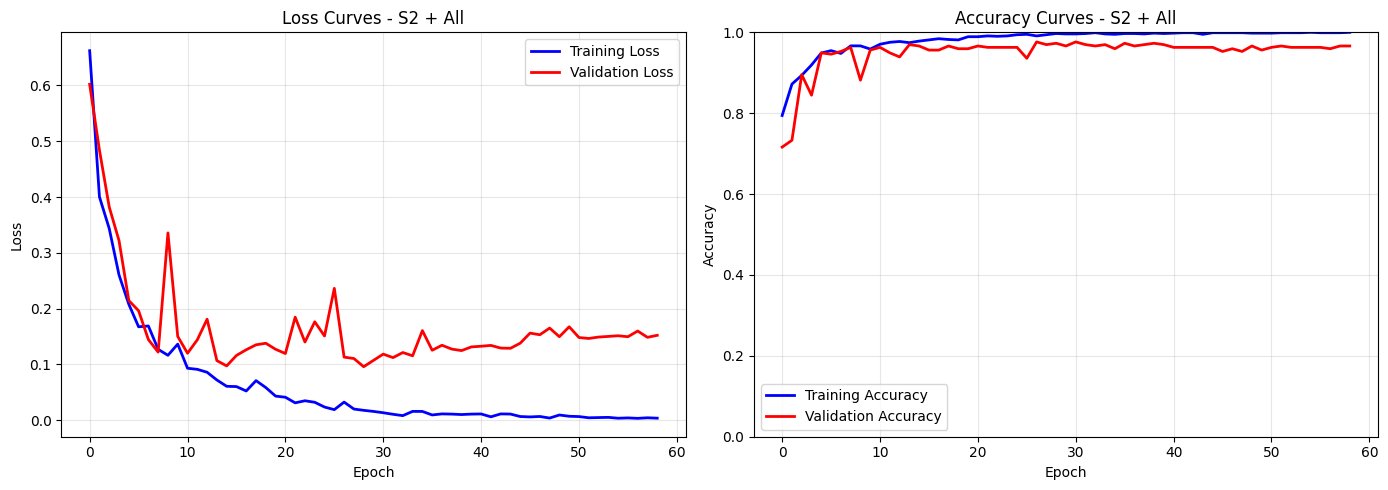

Courbes sauvegardees dans C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part3\outputs


In [45]:
# ============================================
# CELLULE 12 : COURBES D'APPRENTISSAGE DE LA MEILLEURE CONFIGURATION
# ============================================

print("=" * 60)
print("COURBES D'APPRENTISSAGE - MEILLEURE CONFIGURATION")
print("=" * 60)

# Identifier la meilleure configuration
best_config = max(results_part3.items(), key=lambda x: x[1]['accuracy'])[0]
best_accuracy = results_part3[best_config]['accuracy']
print(f"Meilleure configuration: {best_config}")
print(f"Accuracy: {best_accuracy:.4f}")

# Note: Pour avoir les courbes, il faut que train_model_with_history retourne l'historique
# Si vous avez utilise train_model_with_covariates sans historique, vous devez:
# 1. Re-entrainer la meilleure configuration avec historique
# 2. Ou modifier la fonction pour retourner l'historique

# Solution simple: Re-entrainer la meilleure configuration avec historique
print("\nRe-entrainement de la meilleure configuration pour les courbes...")

# Re-creer les loaders pour la meilleure configuration
if best_config == 'Baseline (S2 only)':
    _, _, test_loader = create_loaders_with_covariates(
        X_norm, None, y_encoded, train_idx, val_idx, test_idx, masks
    )
    cov_dim = 0
    X_cov_data = None
elif best_config == 'S2 + Climat':
    _, _, test_loader = create_loaders_with_covariates(
        X_norm, X_climate_norm, y_encoded, train_idx, val_idx, test_idx, masks
    )
    cov_dim = X_climate_norm.shape[1]
    X_cov_data = X_climate_norm
elif best_config == 'S2 + Sol':
    _, _, test_loader = create_loaders_with_covariates(
        X_norm, X_soil_norm, y_encoded, train_idx, val_idx, test_idx, masks
    )
    cov_dim = X_soil_norm.shape[1]
    X_cov_data = X_soil_norm
elif best_config == 'S2 + Topographie':
    _, _, test_loader = create_loaders_with_covariates(
        X_norm, X_topo_norm, y_encoded, train_idx, val_idx, test_idx, masks
    )
    cov_dim = X_topo_norm.shape[1]
    X_cov_data = X_topo_norm
else:  # S2 + All
    _, _, test_loader = create_loaders_with_covariates(
        X_norm, X_all_cov_norm, y_encoded, train_idx, val_idx, test_idx, masks
    )
    cov_dim = X_all_cov_norm.shape[1]
    X_cov_data = X_all_cov_norm

# Re-entrainer avec historique
test_acc, test_f1, history = train_model_with_history(
    X_norm, X_cov_data, y_encoded, train_idx, val_idx, test_idx, masks,
    best_config, cov_dim, device
)

# Tracer les courbes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history['train_loss'], label='Training Loss', color='blue', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', color='red', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title(f'Loss Curves - {best_config}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history['train_acc'], label='Training Accuracy', color='blue', linewidth=2)
axes[1].plot(history['val_acc'], label='Validation Accuracy', color='red', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'Accuracy Curves - {best_config}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "part3_best_config_training_curves.png"), dpi=150)
plt.show()

print(f"Courbes sauvegardees dans {OUTPUT_DIR}")